Import Dataset in to python

In [1]:
import pandas as pd
df=pd.read_csv('/content/train.csv', sep=';')


In [2]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
print(df.shape)

(45211, 17)


In [5]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [7]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [8]:
df['balance']=df['balance'].astype(float)
df['duration']=df['duration'].astype(float)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  int64  
 1   job        45211 non-null  object 
 2   marital    45211 non-null  object 
 3   education  45211 non-null  object 
 4   default    45211 non-null  object 
 5   balance    45211 non-null  float64
 6   housing    45211 non-null  object 
 7   loan       45211 non-null  object 
 8   contact    45211 non-null  object 
 9   day        45211 non-null  int64  
 10  month      45211 non-null  object 
 11  duration   45211 non-null  float64
 12  campaign   45211 non-null  int64  
 13  pdays      45211 non-null  int64  
 14  previous   45211 non-null  int64  
 15  poutcome   45211 non-null  object 
 16  y          45211 non-null  object 
dtypes: float64(2), int64(5), object(10)
memory usage: 5.9+ MB


In [10]:
# Option 1: Using the replace method (Quick and clean)
df['pdays'] = df['pdays'].replace(-1, 0)


In [11]:
y_counts = df['y'].value_counts()
print("Count of 'no' and 'yes' in column 'y':")
display(y_counts)

Count of 'no' and 'yes' in column 'y':


,count
y,
no,39922
yes,5289


In [12]:
# Numerical Columns
Numerical_cols=df.select_dtypes(include=['int64','float64']).columns
Numerical_cols

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [13]:
# CATEGORICAL COLUMNS ANALYSIS
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [14]:
for col in categorical_cols:
    unique_vals=df[col].unique()
    print(f"\nUnique values in '{col}' ({len(unique_vals)} total):")
    print(unique_vals)


Unique values in 'job' (12 total):
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

Unique values in 'marital' (3 total):
['married' 'single' 'divorced']

Unique values in 'education' (4 total):
['tertiary' 'secondary' 'unknown' 'primary']

Unique values in 'default' (2 total):
['no' 'yes']

Unique values in 'housing' (2 total):
['yes' 'no']

Unique values in 'loan' (2 total):
['no' 'yes']

Unique values in 'contact' (3 total):
['unknown' 'cellular' 'telephone']

Unique values in 'month' (12 total):
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

Unique values in 'poutcome' (4 total):
['unknown' 'failure' 'other' 'success']

Unique values in 'y' (2 total):
['no' 'yes']


In [15]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('y', axis=1)
y = df['y']

# Perform stratified splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shapes after stratified splitting:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nValue counts of 'y' in original, training, and testing sets:")
print("Original y:")
display(y.value_counts(normalize=True))
print("\ny_train:")
display(y_train.value_counts(normalize=True))
print("\ny_test:")
display(y_test.value_counts(normalize=True))

Shapes after stratified splitting:
X_train shape: (36168, 16)
y_train shape: (36168,)
X_test shape: (9043, 16)
y_test shape: (9043,)

Value counts of 'y' in original, training, and testing sets:
Original y:


,proportion
y,
no,0.883015
yes,0.116985



y_train:


,proportion
y,
no,0.883018
yes,0.116982



y_test:


,proportion
y,
no,0.883003
yes,0.116997


Cluster Analysis

Mutual Information

In [ ]:
# Concatenate X_train and y_train side-by-side along columns (axis=1)
train_data = pd.concat([X_train, y_train], axis=1)

# Verify the combined dataset shape and check the first few rows
print(f"Combined Training Data Shape: {train_data.shape}")
display(train_data.head())

Combined Training Data Shape: (36168, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
24001,36,technician,divorced,secondary,no,861.0,no,no,telephone,29,aug,140.0,2,0,0,unknown,no
43409,24,student,single,secondary,no,4126.0,no,no,cellular,5,apr,907.0,4,185,7,failure,yes
20669,44,technician,single,secondary,no,244.0,yes,no,cellular,12,aug,1735.0,4,0,0,unknown,yes
18810,48,unemployed,married,secondary,no,0.0,no,no,telephone,31,jul,35.0,11,0,0,unknown,no
23130,38,technician,married,secondary,no,257.0,no,no,cellular,26,aug,57.0,10,0,0,unknown,no


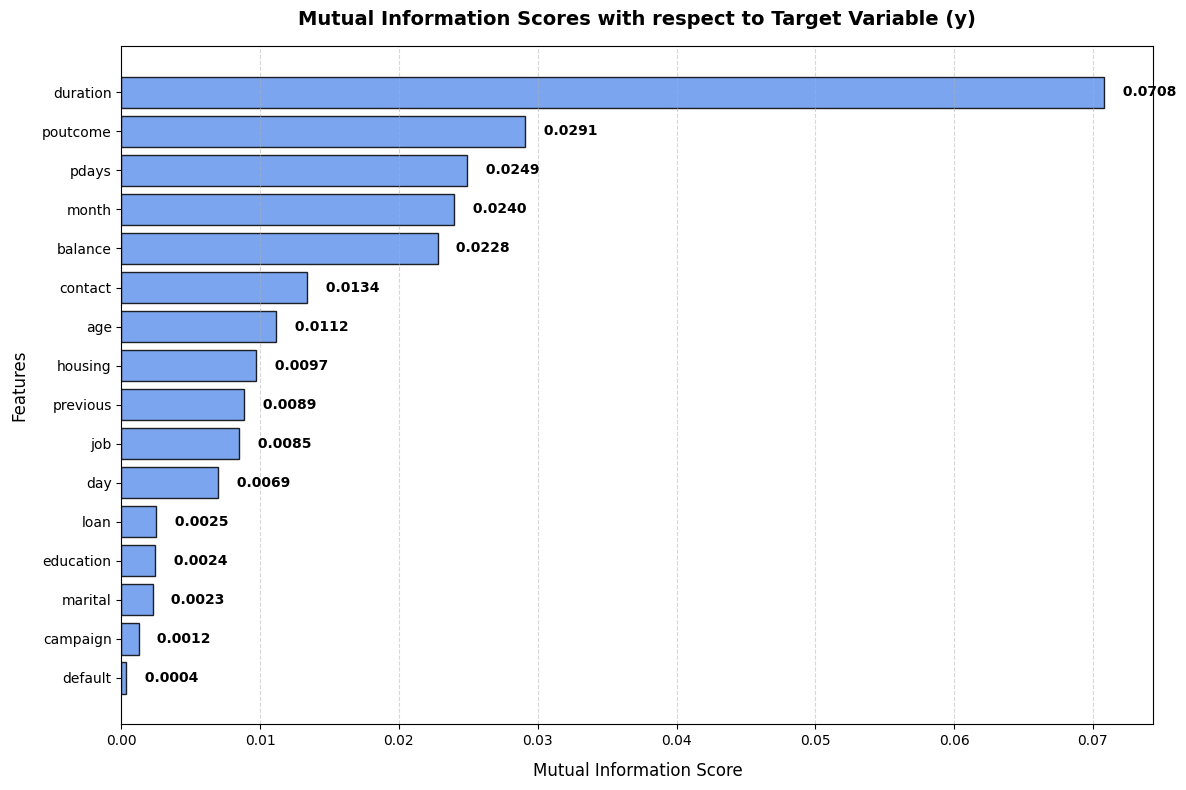

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# 1. Separate features and target from your train_data DataFrame
X_mi = train_data.drop(columns=["y"])
y_mi = train_data["y"]

# Create a copy to encode categorical values safely
X_encoded = X_mi.copy()

# 2. Create a boolean mask identifying categorical (discrete) columns
discrete_mask = X_mi.dtypes == "object"

# 3. Encode categorical string columns into integers (required by mutual_info_classif)
for col in X_mi.columns[discrete_mask]:
    X_encoded[col] = LabelEncoder().fit_transform(X_mi[col].astype(str))

# 4. Encode your target column ('yes'/'no') into 0 and 1
y_encoded = LabelEncoder().fit_transform(y_mi)

# 5. Compute Mutual Information scores
# Passing discrete_features ensures correct non-parametric estimation for mixed types
mi_scores = mutual_info_classif(
    X_encoded, y_encoded, discrete_features=discrete_mask, random_state=42
)

# 6. Store in a pandas Series and sort in ascending order for the horizontal bar plot
mi_scores_series = pd.Series(mi_scores, index=X_mi.columns).sort_values(
    ascending=True
)

# 7. Generate a clean, readable Horizontal Bar Plot
plt.figure(figsize=(12, 8))
bars = plt.barh(
    mi_scores_series.index,
    mi_scores_series.values,
    color="cornflowerblue",
    edgecolor="black",
    alpha=0.85,
)

# Append the numerical MI score value to the tip of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f" {width:.4f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

# Formatting the visualization
plt.title(
    "Mutual Information Scores with respect to Target Variable (y)",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Mutual Information Score", fontsize=12, labelpad=10)
plt.ylabel("Features", fontsize=12, labelpad=10)
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

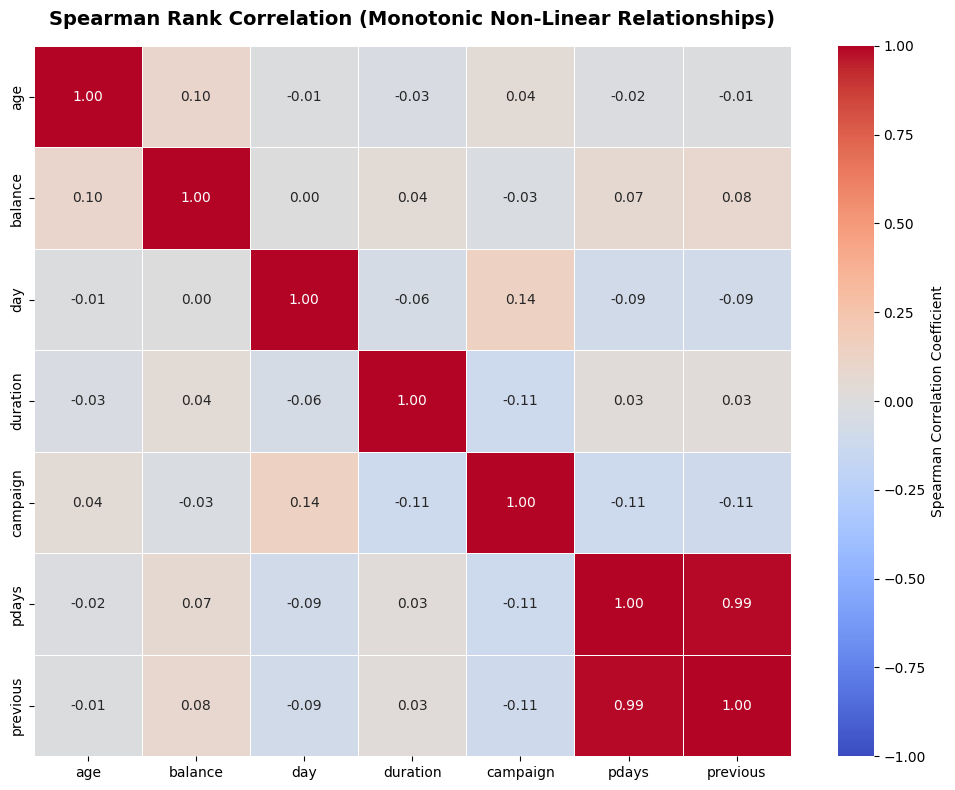

In [ ]:
import seaborn as sns

# 1. Filter out only the numerical columns from your train_data
numerical_cols = train_data.select_dtypes(include=["int64", "float64"]).columns
numerical_df = train_data[numerical_cols]

# 2. Calculate the Spearman Rank Correlation Matrix
spearman_matrix = numerical_df.corr(method="spearman")

# 3. Generate a Heatmap to visualize relationships between numerical variables
plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Spearman Correlation Coefficient"},
)

plt.title(
    "Spearman Rank Correlation (Monotonic Non-Linear Relationships)",
    fontsize=14,
    weight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

EDA

Plot the Distribution of the Target Variable

/tmp/ipykernel_37904/185905855.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='y', data=train_data, palette='Set2', edgecolor='black')


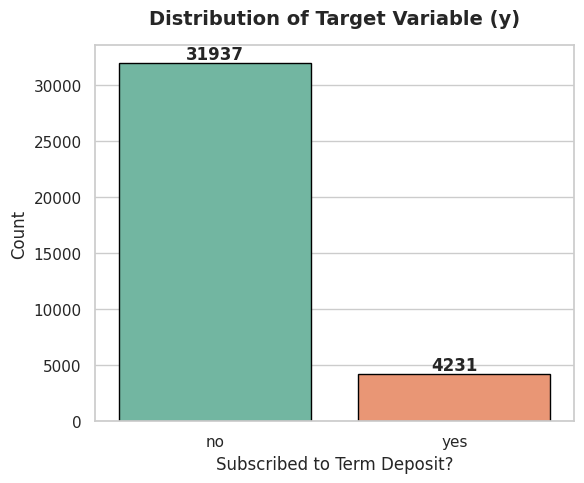

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean aesthetic style for all plots
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 5))
ax = sns.countplot(x='y', data=train_data, palette='Set2', edgecolor='black')

# Add values on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 300, f'{int(height)}', ha="center", weight='bold')

plt.title('Distribution of Target Variable (y)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Subscribed to Term Deposit?', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_37904/1828456052.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=train_data, ax=axes[i], palette='Pastel1', width=0.5)
/tmp/ipykernel_37904/1828456052.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=train_data, ax=axes[i], palette='Pastel1', width=0.5)
/tmp/ipykernel_37904/1828456052.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=train_data, ax=axes[i], palette='Pastel1', width=0.5)


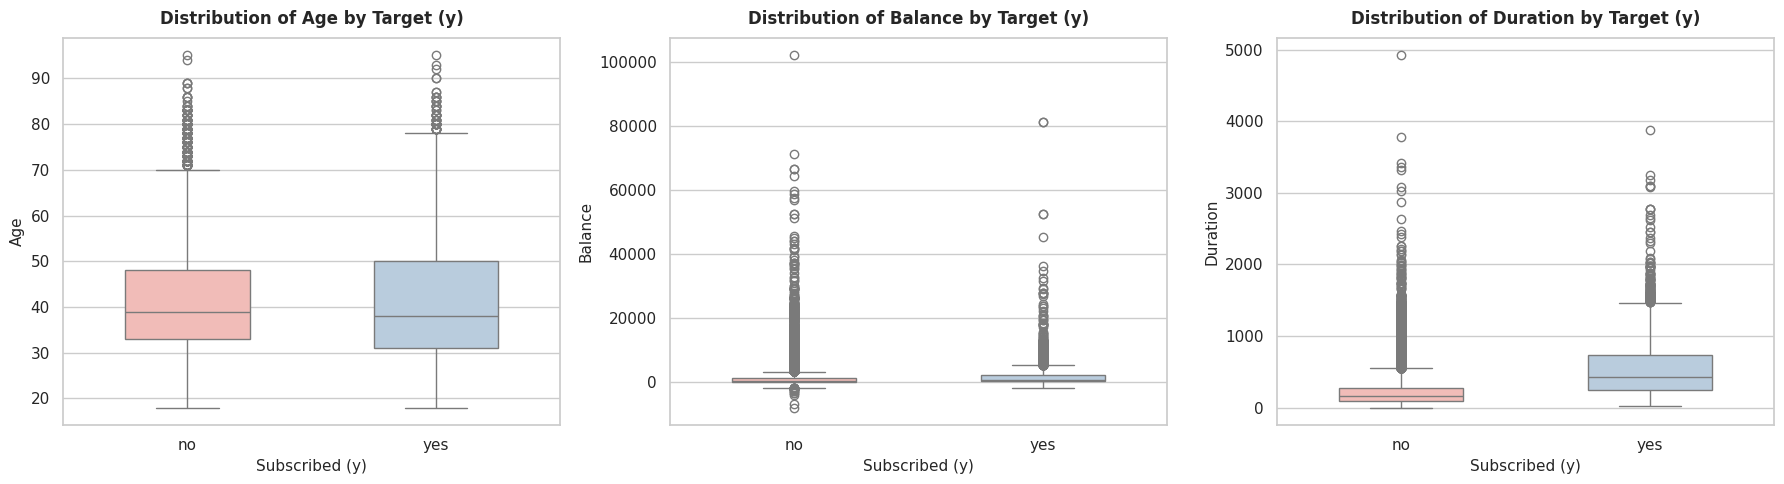

In [ ]:
# List of the core numerical features to visualize
num_features = ['age', 'balance', 'duration']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_features):
    sns.boxplot(x='y', y=col, data=train_data, ax=axes[i], palette='Pastel1', width=0.5)
    axes[i].set_title(f'Distribution of {col.capitalize()} by Target (y)', fontsize=12, weight='bold', pad=10)
    axes[i].set_xlabel('Subscribed (y)', fontsize=11)
    axes[i].set_ylabel(col.capitalize(), fontsize=11)

plt.tight_layout()
plt.show()

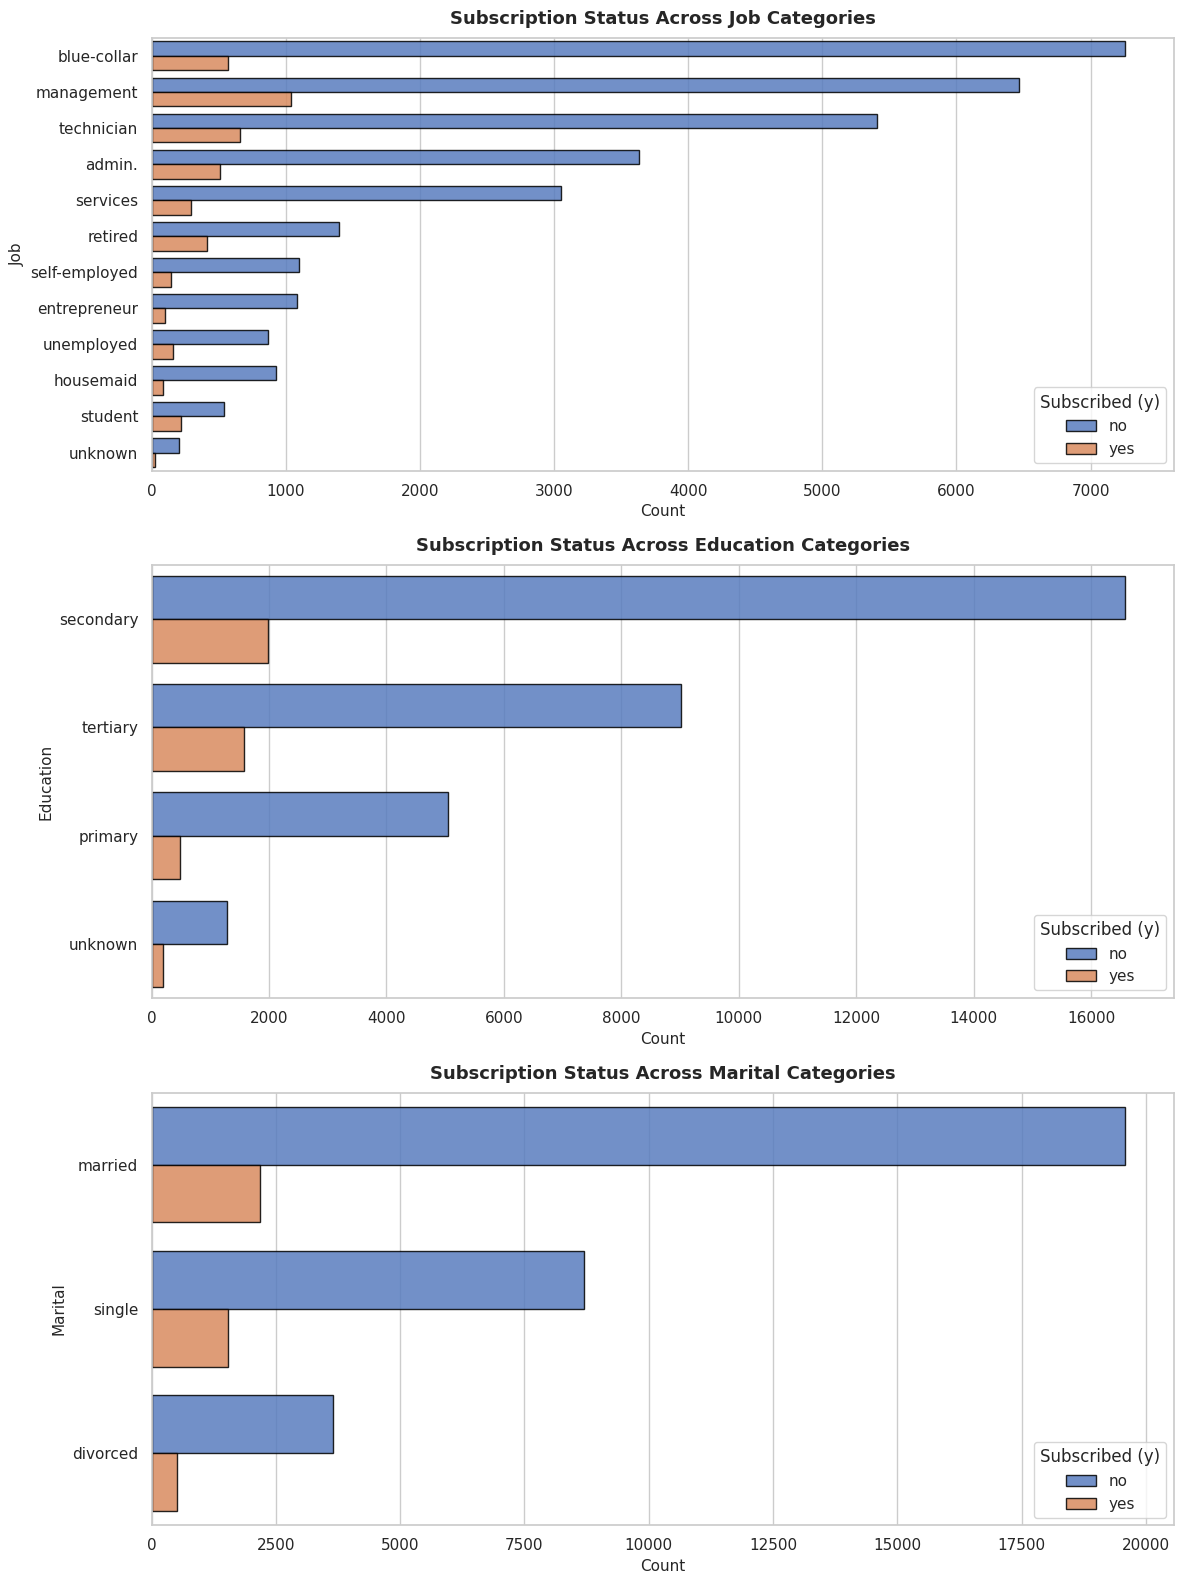

In [ ]:
# Select core categorical features for visualization
cat_features = ['job', 'education', 'marital']

fig, axes = plt.subplots(3, 1, figsize=(12, 16))

for i, col in enumerate(cat_features):
    # Calculate order by total frequency to keep the bar chart organized
    order = train_data[col].value_counts().index

    sns.countplot(
        y=col,
        hue='y',
        data=train_data,
        ax=axes[i],
        order=order,
        palette='muted',
        edgecolor='black',
        alpha=0.85
    )

    axes[i].set_title(f'Subscription Status Across {col.capitalize()} Categories', fontsize=13, weight='bold', pad=10)
    axes[i].set_xlabel('Count', fontsize=11)
    axes[i].set_ylabel(col.capitalize(), fontsize=11)
    axes[i].legend(title='Subscribed (y)', loc='lower right')

plt.tight_layout()
plt.show()

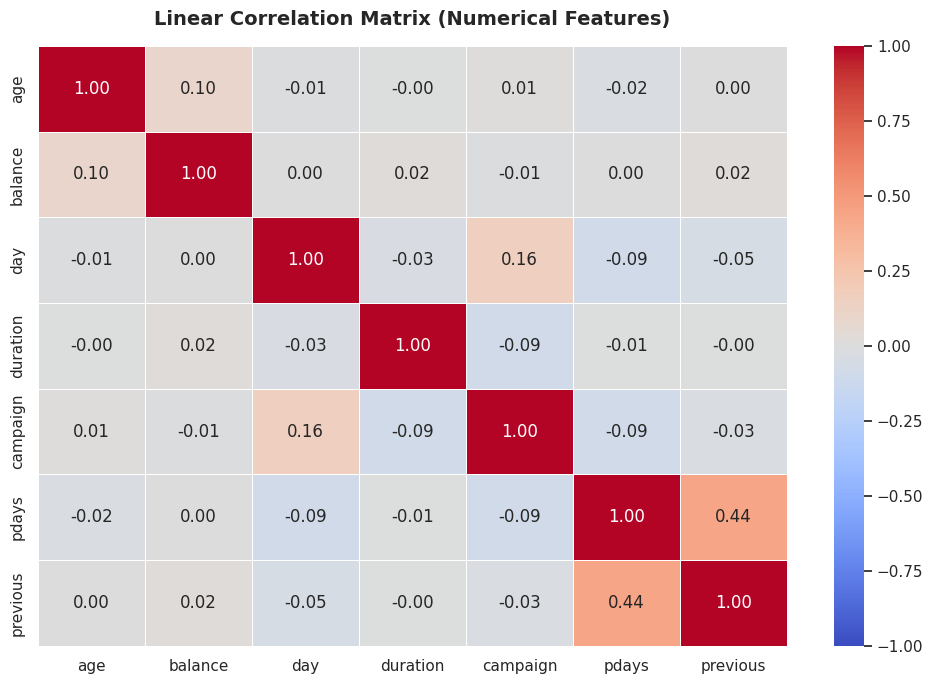

In [ ]:
# Extract all numerical attributes
numerical_df = train_data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 7))
sns.heatmap(
    numerical_df.corr(method='pearson'),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Linear Correlation Matrix (Numerical Features)', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
pip install kmodes gower

In [ ]:

# Let's assume you've chosen k=4 clusters from an elbow plot analysis
num_clusters = 2
print(f"Training K-Prototypes model with k={num_clusters} on the training dataset...")

kproto = KPrototypes(n_clusters=num_clusters, init='Huang', random_state=42, n_init=3)
cluster_labels = kproto.fit_predict(data_matrix, categorical=categorical_indices)

# Add cluster assignments back to the scaled training dataframe
# Removed: df['Cluster'] = cluster_labels (due to length mismatch with cluster_labels which are for X_train)
df_scaled['Cluster'] = cluster_labels

print("Clustering complete!")

# =====================================================================
# STEP 4: STRATIFIED SAMPLING FOR SILHOUETTE EVALUATION
# =====================================================================
print("\nSampling dataset for Gower Silhouette evaluation to save memory...")
# We take a sample of 5,000 rows, ensuring all clusters are represented proportionally
sample_size = 5000

# Fix: Perform stratified sampling more explicitly to ensure 'Cluster' column is retained
sampled_dfs = []
unique_clusters = sorted(df_scaled['Cluster'].unique())
for cluster_id in unique_clusters:
    cluster_df = df_scaled[df_scaled['Cluster'] == cluster_id]
    num_samples_from_cluster = min(len(cluster_df), sample_size // num_clusters)
    if num_samples_from_cluster > 0:
        sampled_dfs.append(cluster_df.sample(n=num_samples_from_cluster, random_state=42))

df_sample = pd.concat(sampled_dfs)


# Extract features and labels from the sample
X_sample = df_sample.drop(columns=['Cluster'])
y_sample = df_sample['Cluster'].values

# Create a boolean mask indicating which features are categorical for the gower library
is_categorical_mask = [col in categorical_cols for col in X_sample.columns]

# =====================================================================
# STEP 5: COMPUTE GOWER DISTANCE MATRIX
# =====================================================================
print("Calculating Gower distance matrix for the sample...")
# This creates a distance matrix of size (sample_size x sample_size)
gower_matrix = gower.gower_matrix(X_sample, cat_features=is_categorical_mask)

# =====================================================================
# STEP 6: CALCULATE SILHOUETTE SCORE
# =====================================================================
print("Computing Silhouette Score...")
# We use metric='precomputed' because we are passing the explicit distance matrix
sil_score = silhouette_score(gower_matrix, y_sample, metric='precomputed')

print(f"\n=========================================")
print(f"RESULTS FOR k = {num_clusters}")
print(f"Gower Silhouette Score: {sil_score:.4f}")
print(f"=========================================")

# =====================================================================
# STEP 7: INTERPRET CLUSTER SIZES
# =====================================================================
print("\nProportional Cluster Sizes across the training dataset:")
print(df_scaled['Cluster'].value_counts(normalize=True) * 100)


Training K-Prototypes model with k=2 on the training dataset...
Clustering complete!

Sampling dataset for Gower Silhouette evaluation to save memory...
Calculating Gower distance matrix for the sample...
Computing Silhouette Score...

RESULTS FOR k = 2
Gower Silhouette Score: 0.0621

Proportional Cluster Sizes across the training dataset:
Cluster
0    50.254369
1    49.745631
Name: proportion, dtype: float64


Successfully generated and saved cluster_visualization.png


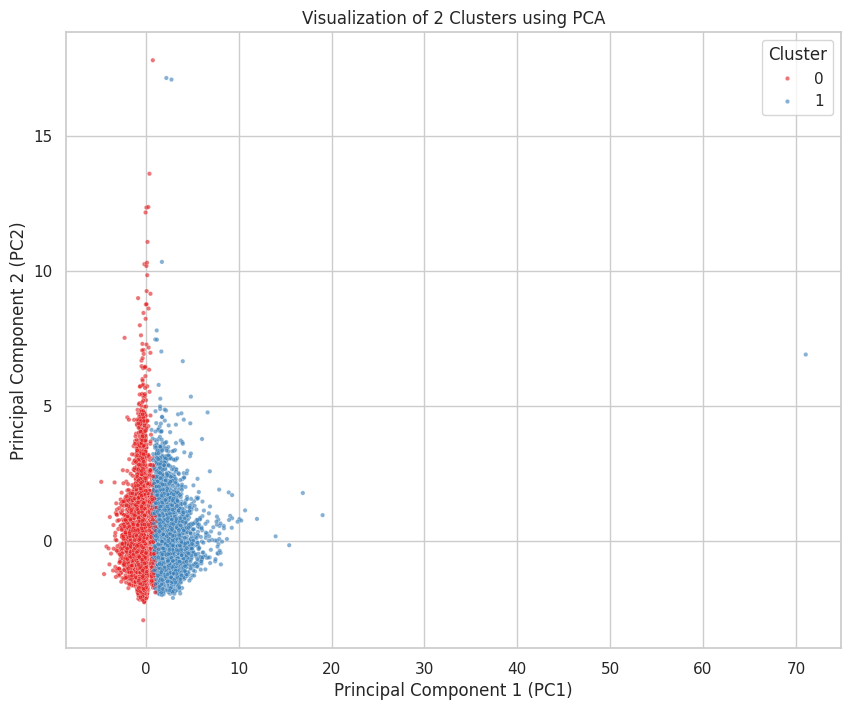

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA



# 2. Define numerical and categorical columns
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'] # Removed 'y'

# 3. Build a preprocessing pipeline to handle mixed data types
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_cols)
    ])

# Transform the dataset into a purely numeric matrix
X_processed = preprocessor.fit_transform(X_train)

# 4. Perform K-Means clustering with exactly 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_processed)

# 5. Apply PCA to reduce the data dimensions to 2D for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

# Create a clean DataFrame combining the principal components and cluster labels
plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
plot_df['Cluster'] = clusters

# 6. Generate the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=plot_df, palette='Set1', alpha=0.6, s=10)
plt.title('Visualization of 2 Clusters using PCA')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster')

# Save the plot
plt.savefig('cluster_visualization.png', dpi=300, bbox_inches='tight')
print("Successfully generated and saved cluster_visualization.png")

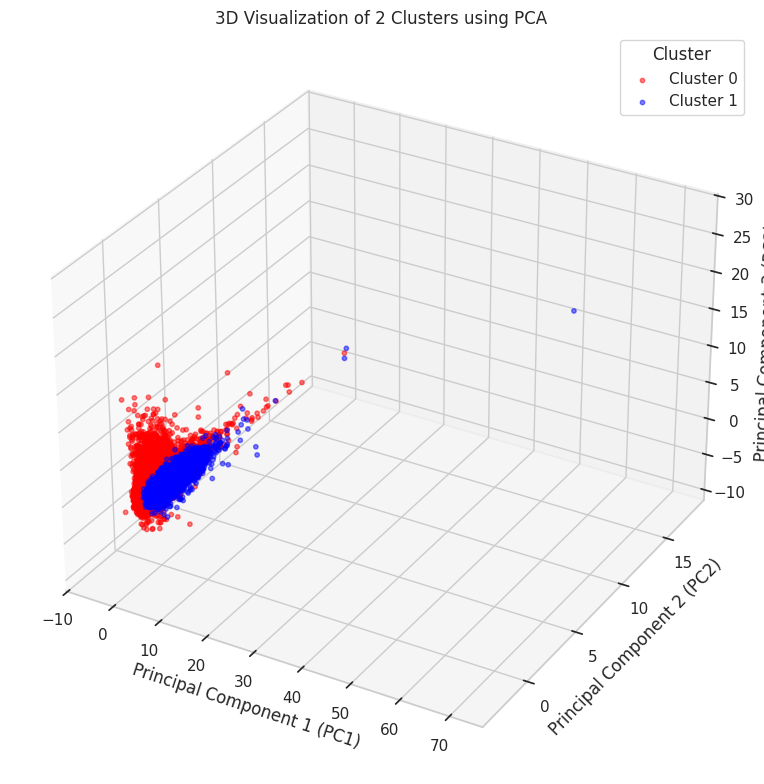

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# 2. Define features
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'] # Removed 'y'

# 3. Preprocess mixed data types
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X_train)

# 4. Fit KMeans with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_processed)

# 5. Apply PCA to get 3 Principal Components
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_processed)

# Create a DataFrame for plotting
plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
plot_df['Cluster'] = clusters

# 6. Generate the 3D plot using a subplot keyword projection
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 8))

# Define colors for the 2 clusters
colors = {0: 'red', 1: 'blue'}

# Plot each cluster individually for clean legend representation
for cluster_id, color in colors.items():
    subset = plot_df[plot_df['Cluster'] == cluster_id]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'],
               c=color, label=f'Cluster {cluster_id}', alpha=0.5, s=10)

# Label axes and title
ax.set_title('3D Visualization of 2 Clusters using PCA')
ax.set_xlabel('Principal Component 1 (PC1)')
ax.set_ylabel('Principal Component 2 (PC2)')
ax.set_zlabel('Principal Component 3 (PC3)')
ax.legend(title='Cluster')

# Save the 3D plot
plt.tight_layout()
plt.savefig('cluster_visualization_3d.png', dpi=300, bbox_inches='tight')

Scaling numerical features...

Starting multi-cluster Gower Silhouette analysis...

[Evaluating k = 2]
-> Gower Silhouette Score for k=2: 0.0611
Cluster Sizes Distribution (%):
{0: 50.3, 1: 49.7}

[Evaluating k = 3]
-> Gower Silhouette Score for k=3: 0.0965
Cluster Sizes Distribution (%):
{1: 52.83, 2: 32.89, 0: 14.28}

[Evaluating k = 4]
-> Gower Silhouette Score for k=4: 0.0542
Cluster Sizes Distribution (%):
{1: 42.99, 2: 39.55, 3: 14.58, 0: 2.88}

[Evaluating k = 5]
-> Gower Silhouette Score for k=5: 0.0474
Cluster Sizes Distribution (%):
{2: 30.99, 1: 26.9, 0: 21.72, 3: 13.35, 4: 7.04}

[Evaluating k = 6]
-> Gower Silhouette Score for k=6: 0.0351
Cluster Sizes Distribution (%):
{4: 27.87, 1: 27.57, 3: 21.68, 0: 13.09, 2: 6.59, 5: 3.19}

[Evaluating k = 7]
-> Gower Silhouette Score for k=7: 0.0183
Cluster Sizes Distribution (%):
{1: 27.05, 0: 27.01, 2: 21.45, 6: 12.92, 3: 6.6, 5: 3.06, 4: 1.92}

FINAL RESULTS SUMMARY
Clusters (k) = 2 | Silhouette Score = 0.0611
Clusters (k) = 3 | S

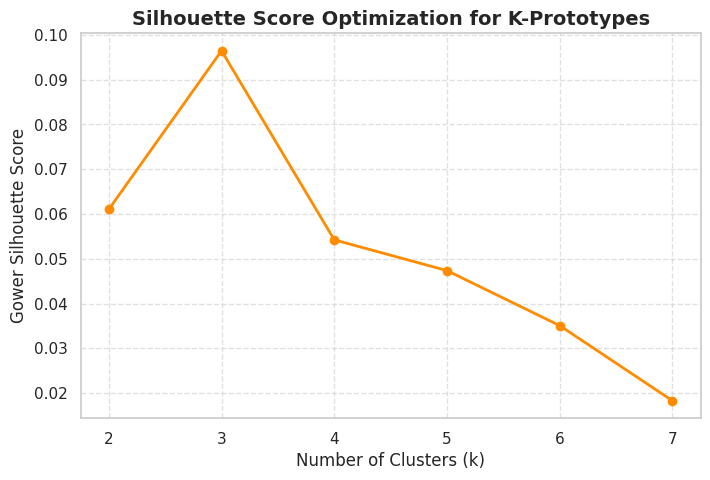

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from kmodes.kprototypes import KPrototypes
import gower


# Define column groups explicitly
categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                    'loan', 'contact', 'month', 'poutcome']
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Get categorical column indices required by K-Prototypes
categorical_indices = [X_train.columns.get_loc(col) for col in categorical_cols]

# =====================================================================
# STEP 2: PREPROCESS NUMERICAL DATA
# =====================================================================
print("Scaling numerical features...")
scaler = StandardScaler()
df_scaled = X_train.copy()
df_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Convert processed dataframe to matrix for the algorithm
data_matrix = df_scaled.to_numpy()

# =====================================================================
# LOOPING THROUGH K = 2 TO 7 FOR SILHOUETTE EVALUATION
# =====================================================================
cluster_range = range(2, 8)  # Evaluates 2, 3, 4, 5, 6, 7
silhouette_scores = []
sample_size = 5000

print("\nStarting multi-cluster Gower Silhouette analysis...")
print("=========================================================")

for num_clusters in cluster_range:
    print(f"\n[Evaluating k = {num_clusters}]")

    # 1. Train K-Prototypes
    kproto = KPrototypes(n_clusters=num_clusters, init='Huang', random_state=42, n_init=3)
    cluster_labels = kproto.fit_predict(data_matrix, categorical=categorical_indices)

    # Assign labels to our scaled dataframe loop instance
    df_scaled['Cluster'] = cluster_labels

    # 2. Stratified Sampling to preserve memory during Gower matrix computation
    sampled_dfs = []
    unique_clusters = sorted(df_scaled['Cluster'].unique())
    for cluster_id in unique_clusters:
        cluster_df = df_scaled[df_scaled['Cluster'] == cluster_id]
        num_samples_from_cluster = min(len(cluster_df), sample_size // num_clusters)
        if num_samples_from_cluster > 0:
            sampled_dfs.append(cluster_df.sample(n=num_samples_from_cluster, random_state=42))

    df_sample = pd.concat(sampled_dfs)

    # Extract features and labels from the sample
    X_sample = df_sample.drop(columns=['Cluster'])
    y_sample = df_sample['Cluster'].values

    # Boolean mask for Gower library
    is_categorical_mask = [col in categorical_cols for col in X_sample.columns]

    # 3. Compute Gower Distance Matrix for the sample
    gower_matrix = gower.gower_matrix(X_sample, cat_features=is_categorical_mask)

    # 4. Calculate Silhouette Score
    sil_score = silhouette_score(gower_matrix, y_sample, metric='precomputed')
    silhouette_scores.append(sil_score)

    print(f"-> Gower Silhouette Score for k={num_clusters}: {sil_score:.4f}")
    print("Cluster Sizes Distribution (%):")
    print((df_scaled['Cluster'].value_counts(normalize=True) * 100).round(2).to_dict())

# =====================================================================
# POST-EVALUATION SUMMARY & PLOT
# =====================================================================
print("\n=========================================================")
print("FINAL RESULTS SUMMARY")
print("=========================================================")
for k, score in zip(cluster_range, silhouette_scores):
    print(f"Clusters (k) = {k} | Silhouette Score = {score:.4f}")

# Plot the Silhouette Scores across different cluster numbers
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouette_scores, marker='o', linestyle='-', color='darkorange', linewidth=2)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Gower Silhouette Score', fontsize=12)
plt.title('Silhouette Score Optimization for K-Prototypes', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(cluster_range)

# Highlight the best score
best_k = list(cluster_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
print(f"\nMathematically Optimal Cluster Count based on Silhouette Score: k = {best_k} ({best_score:.4f})")

plt.savefig('gower_silhouette_scores.png', dpi=300, bbox_inches='tight')
print("Silhouette curve visualization saved as 'gower_silhouette_scores.png'")

Successfully generated and saved cluster_visualization_3k.png


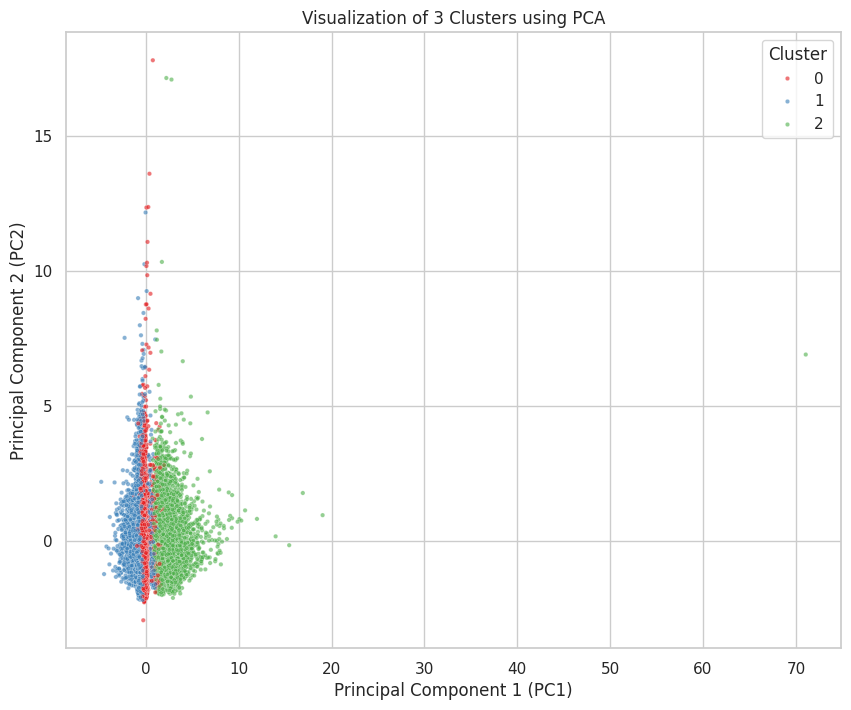

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Define numerical and categorical columns
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'] # Removed 'y'

# 3. Build a preprocessing pipeline to handle mixed data types
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_cols)
    ])

# Transform the dataset into a purely numeric matrix
# Note: Ensure X_train is defined prior to running this segment
X_processed = preprocessor.fit_transform(X_train)

# 4. Perform K-Means clustering with exactly 3 clusters
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_processed)

# 5. Apply PCA to reduce the data dimensions to 2D for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

# Create a clean DataFrame combining the principal components and cluster labels
plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
plot_df['Cluster'] = clusters

# 6. Generate the scatter plot
plt.figure(figsize=(10, 8))
# 'Set1' or 'viridis' palettes automatically handle 3 distinct color mappings gracefully
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=plot_df, palette='Set1', alpha=0.6, s=10)
plt.title(f'Visualization of {num_clusters} Clusters using PCA')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')

# Explicitly ensure the legend handles the categorical cluster categories cleanly
plt.legend(title='Cluster')

# Save the plot
plt.savefig('cluster_visualization_3k.png', dpi=300, bbox_inches='tight')
print("Successfully generated and saved cluster_visualization_3k.png")

Successfully generated and saved cluster_visualization_3d_3k.png


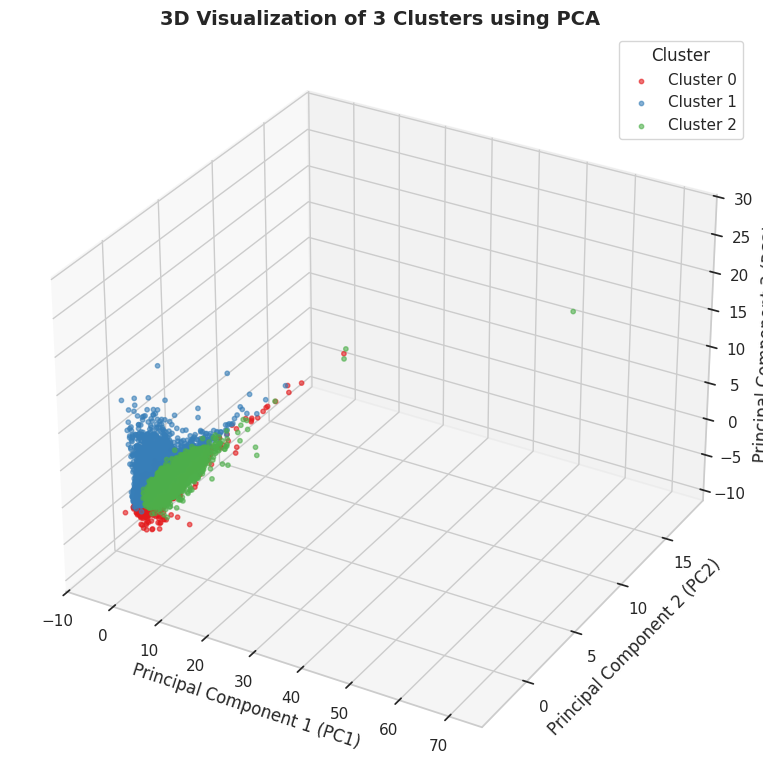

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Define numerical and categorical columns
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'] # Removed 'y'

# 3. Build a preprocessing pipeline to handle mixed data types
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_cols)
    ])

# Transform the dataset into a purely numeric matrix
# Note: Ensure X_train is defined prior to running this segment
X_processed = preprocessor.fit_transform(X_train)

# 4. Perform K-Means clustering with exactly 3 clusters
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_processed)

# 5. Apply PCA to reduce the data dimensions to 3D for plotting
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_processed)

# Create a clean DataFrame combining the principal components and cluster labels
plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
plot_df['Cluster'] = clusters

# 6. Generate the 3D scatter plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 8))

# Define distinct colors for the 3 clusters
colors = {0: '#E41A1C', 1: '#377EB8', 2: '#4DAF4A'}  # Red, Blue, Green

# Plot each cluster individually for clean legend rendering
for cluster_id, color in colors.items():
    subset = plot_df[plot_df['Cluster'] == cluster_id]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'],
               c=color, label=f'Cluster {cluster_id}', alpha=0.6, s=10)

# Set titles and axis labels
ax.set_title(f'3D Visualization of {num_clusters} Clusters using PCA', fontsize=14, fontweight='bold')
ax.set_xlabel('Principal Component 1 (PC1)')
ax.set_ylabel('Principal Component 2 (PC2)')
ax.set_zlabel('Principal Component 3 (PC3)')

# Place the legend
ax.legend(title='Cluster')

# Save the 3D plot
plt.tight_layout()
plt.savefig('cluster_visualization_3d_3k.png', dpi=300, bbox_inches='tight')
print("Successfully generated and saved cluster_visualization_3d_3k.png")